# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

from encoder_quant import (
    image_encoder_monkey_patch, 
    ImageEncoderViTObserver
) 
from utils import get_activation_boxplot, to_numpy,  inference_image
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt
from quant_utils import SignProcessor, DoNothingProcessor, AttnBasedProcessor
from segment_anything.modeling.image_encoder import (
    Attention,
    Block,
    ImageEncoderViT,
)
from quant_utils import ImageEncoderProcessor
from segment_anything.modeling.image_encoder import (
    window_partition,
    window_unpartition,
)
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwri

In [2]:

model_type = 'vit_l'
checkpoint_path= './pretrained_checkpoint/sam_hq_vit_l.pth'
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')


predictor = SamPredictor(sam)
processor = ImageEncoderProcessor('attn') 
# processor = DoNothingProcessor('attn') 
# processor = SignProcessor('attn') 
# processor.calibrate(
    # predictor=predictor, 
    # modules=(),
    # num_samples=1,
# )
predictor = SamPredictor(sam)
image_encoder_monkey_patch(predictor.model, processor, n_bits=8, debug=True)


<All keys matched successfully>
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470


(1000, 894, 3)


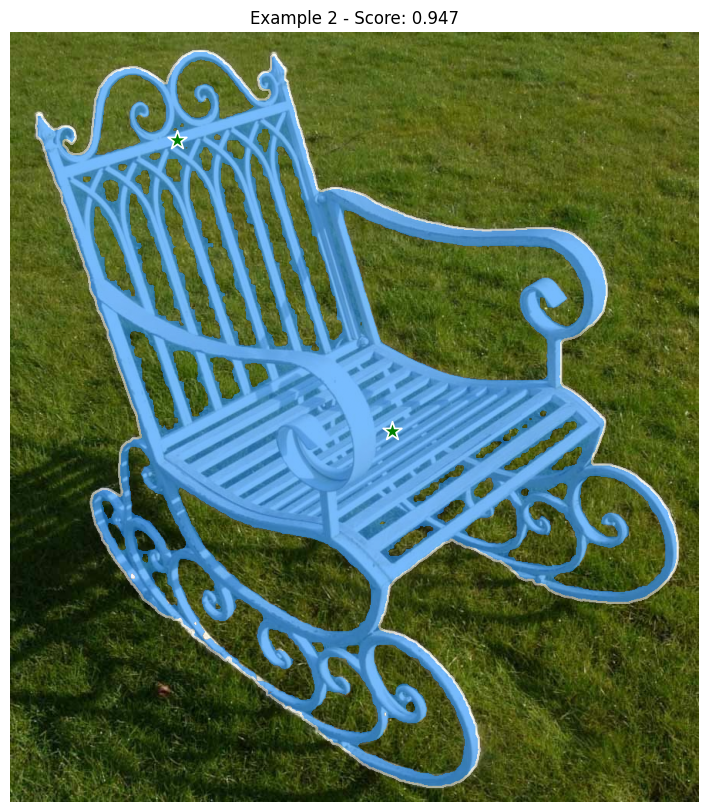

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],
       shape=(1, 1000, 894)),
 array([0.9474949], dtype=float32),
 array([[[ -9.9486265, -11.735071 ,  -9.523135 , ...,  -8.391887 ,
           -9.492323 ,  -9.203416 ],
         [-10.1646   , -12.685325 ,  -9.053842 , ..., -10.022658 ,
          -10.579619 , -10.573873 ],
         [ -9.825417 , -12.260954 , -10.196236 , ...,  -9.273427 ,
          -11.947282 , -11.816063 ],
         ...,
         [ -7.284284 , -10.283312 ,  -9.66228  , ...,  -4.3984666,
           -5.720779 ,  -5.2953987],
         [ -9.295828 , -10.924978 , -10.34195  , ...,  -5.3154974,
           -6.928862 ,  -6.430451 ],
         [ -9.777107 , -11.003738 , 

In [3]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
inference_image(predictor, image_dir='./input_imgs/', example_idx=2, show_image=True)

In [4]:
ImageEncoderViTObserver.attention_score.keys()

dict_keys(['block_0_x', 'block_0_attn', 'block_0_attn_mean', 'block_0_attn_ori', 'block_0_q_hat', 'block_0_k_hat', 'block_0_v_hat', 'block_0_q_mean', 'block_0_v_mean', 'block_1_x', 'block_1_attn', 'block_1_attn_mean', 'block_1_attn_ori', 'block_1_q_hat', 'block_1_k_hat', 'block_1_v_hat', 'block_1_q_mean', 'block_1_v_mean', 'block_2_x', 'block_2_attn', 'block_2_attn_mean', 'block_2_attn_ori', 'block_2_q_hat', 'block_2_k_hat', 'block_2_v_hat', 'block_2_q_mean', 'block_2_v_mean', 'block_3_x', 'block_3_attn', 'block_3_attn_mean', 'block_3_attn_ori', 'block_3_q_hat', 'block_3_k_hat', 'block_3_v_hat', 'block_3_q_mean', 'block_3_v_mean', 'block_4_x', 'block_4_attn', 'block_4_attn_mean', 'block_4_attn_ori', 'block_4_q_hat', 'block_4_k_hat', 'block_4_v_hat', 'block_4_q_mean', 'block_4_v_mean', 'block_5_x', 'block_5_attn', 'block_5_attn_mean', 'block_5_attn_ori', 'block_5_q_hat', 'block_5_k_hat', 'block_5_v_hat', 'block_5_q_mean', 'block_5_v_mean', 'block_6_x', 'block_6_attn', 'block_6_attn_mean

In [5]:

def get_attention_map_hat(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn'][0]
    return attn

def get_attention_map_mean(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn_mean'][0]
    return attn


def get_attention_map_ori(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn_ori'][0]
    return attn


def get_feature(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_x'][0]
    return x
def get_q(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q_hat'][0]
    return x
def get_k(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_k_hat'][0]
    return x
def get_v(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v_hat'][0]
    return x

def get_q_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q_mean'][0]
    return x
def get_v_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v_mean'][0]
    return x




In [6]:
get_attention_map_mean(5).shape

(16, 1, 4096)

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot  as plt

def cal_energy(X:torch.Tensor, margin=0.9):
    """
    Calculate the energy of the input tensor.
    """
    X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
    score_map = F.elu(X @ X.transpose(-1, -2) - margin)
    scores = score_map.mean(-1)
    return scores

def recal_attn(q, k, v):
    attn = (q * 1/8) @ k.transpose(-2, -1)
    attn = attn.softmax(dim=-1)
    return attn

head_idx = 0
layer_idx = 5 
# q = get_q(layer_idx)[head_idx]
# k = get_k(layer_idx)[head_idx]
# v = get_k(layer_idx)[head_idx]
attn = get_attention_map_hat(layer_idx)
attn_mean = get_attention_map_mean(layer_idx)
attn_ori= get_attention_map_ori(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))

def show_attn_map(attn_map):
    fig, axes = plt.subplots(2,8,figsize=(30,8))
    for i in range(8):
        axes[0][i].imshow(attn_map[2*i].mean(0).reshape(64,64))
        axes[1][i].imshow(attn_map[2*i+1].mean(0).reshape(64,64))
    # print(energy_scores.shape)

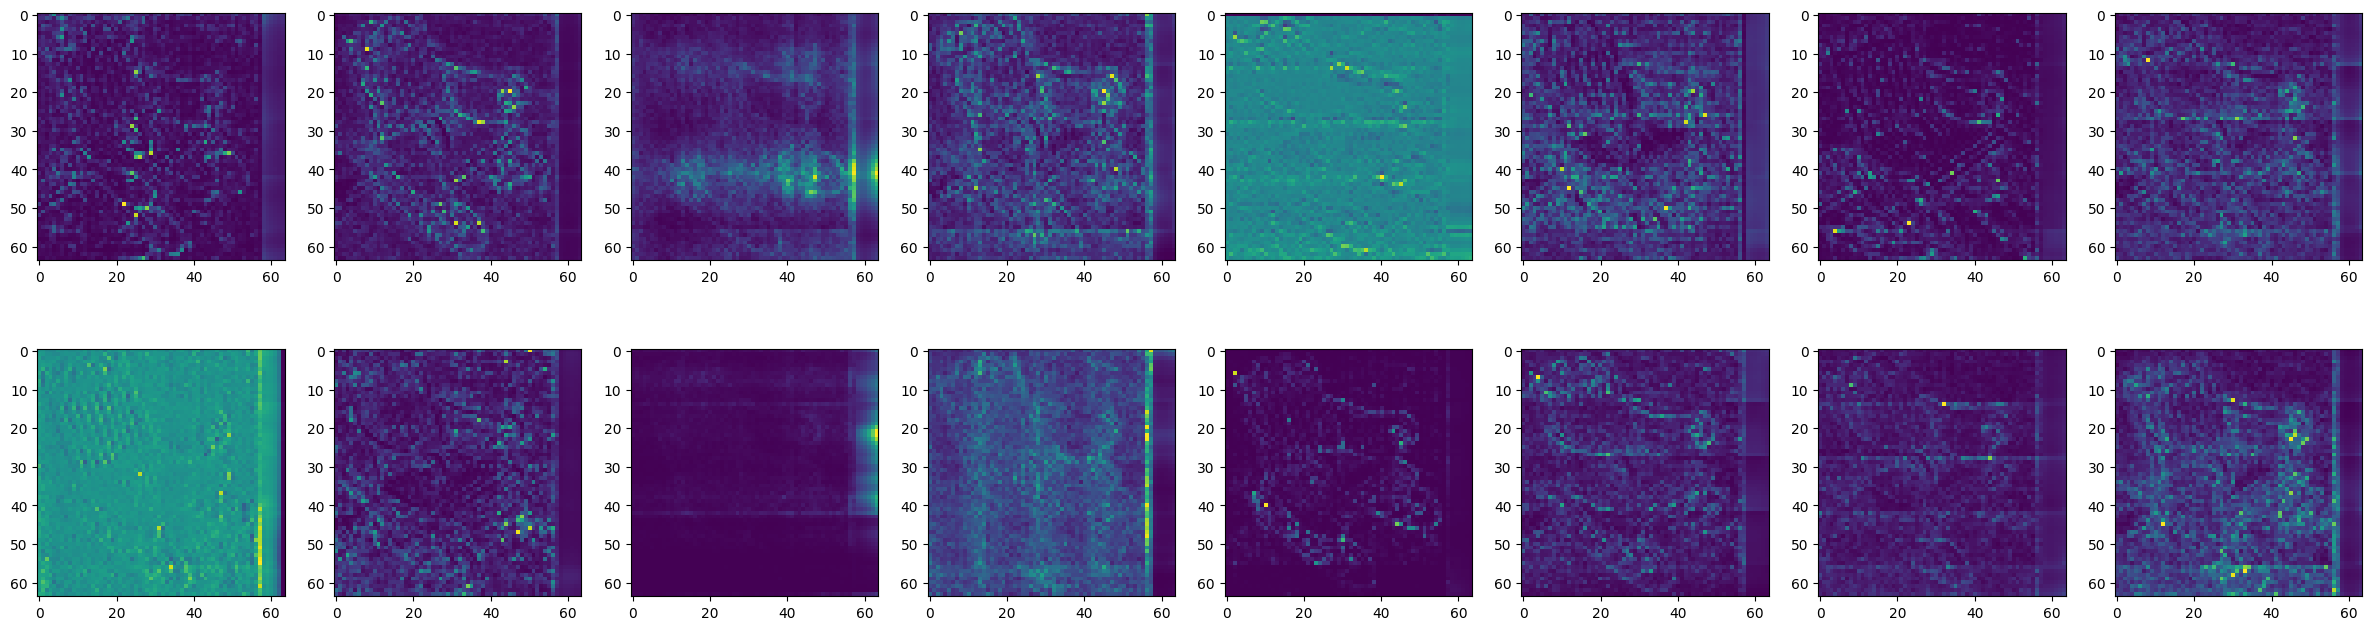

In [13]:

show_attn_map(attn_ori)


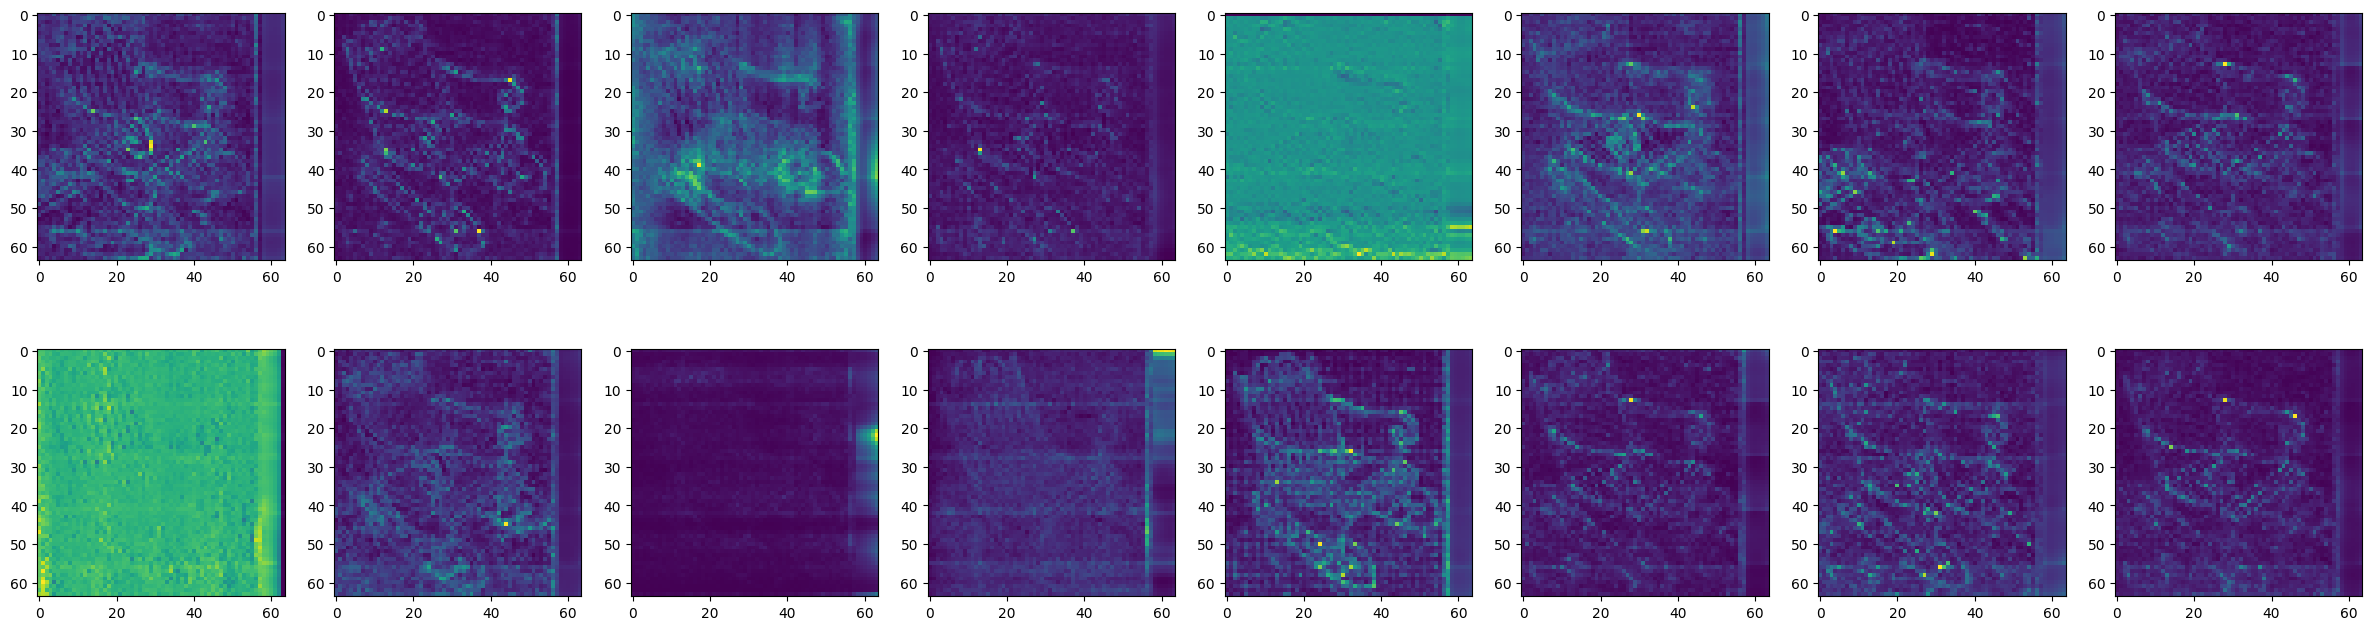

In [14]:
show_attn_map(attn)

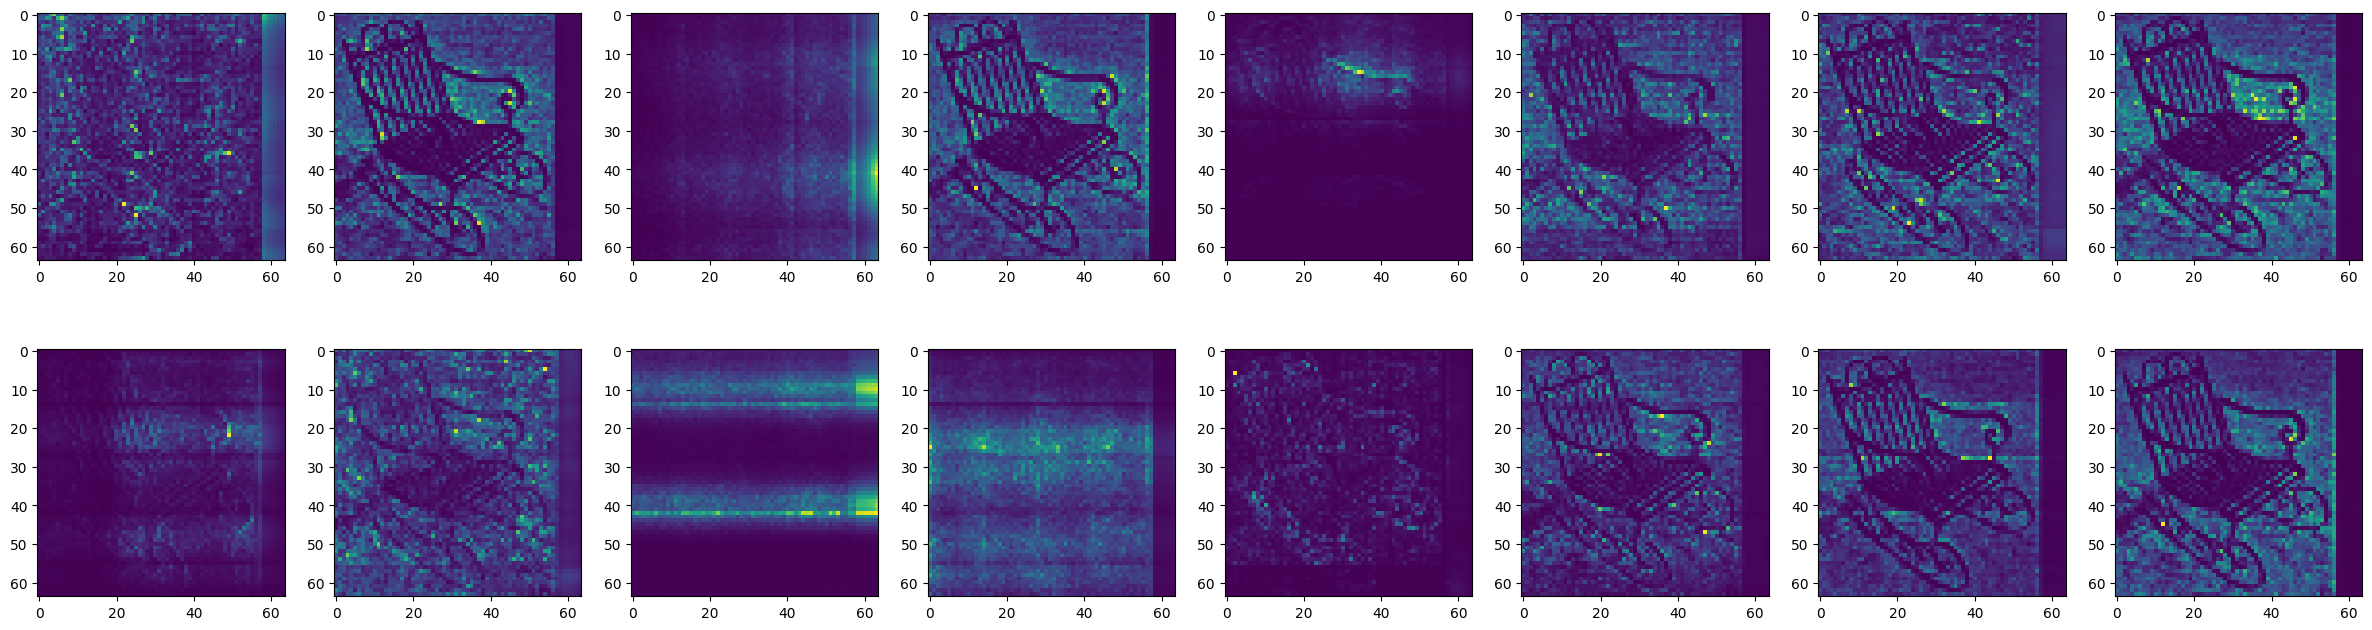

In [15]:
show_attn_map(attn_mean)

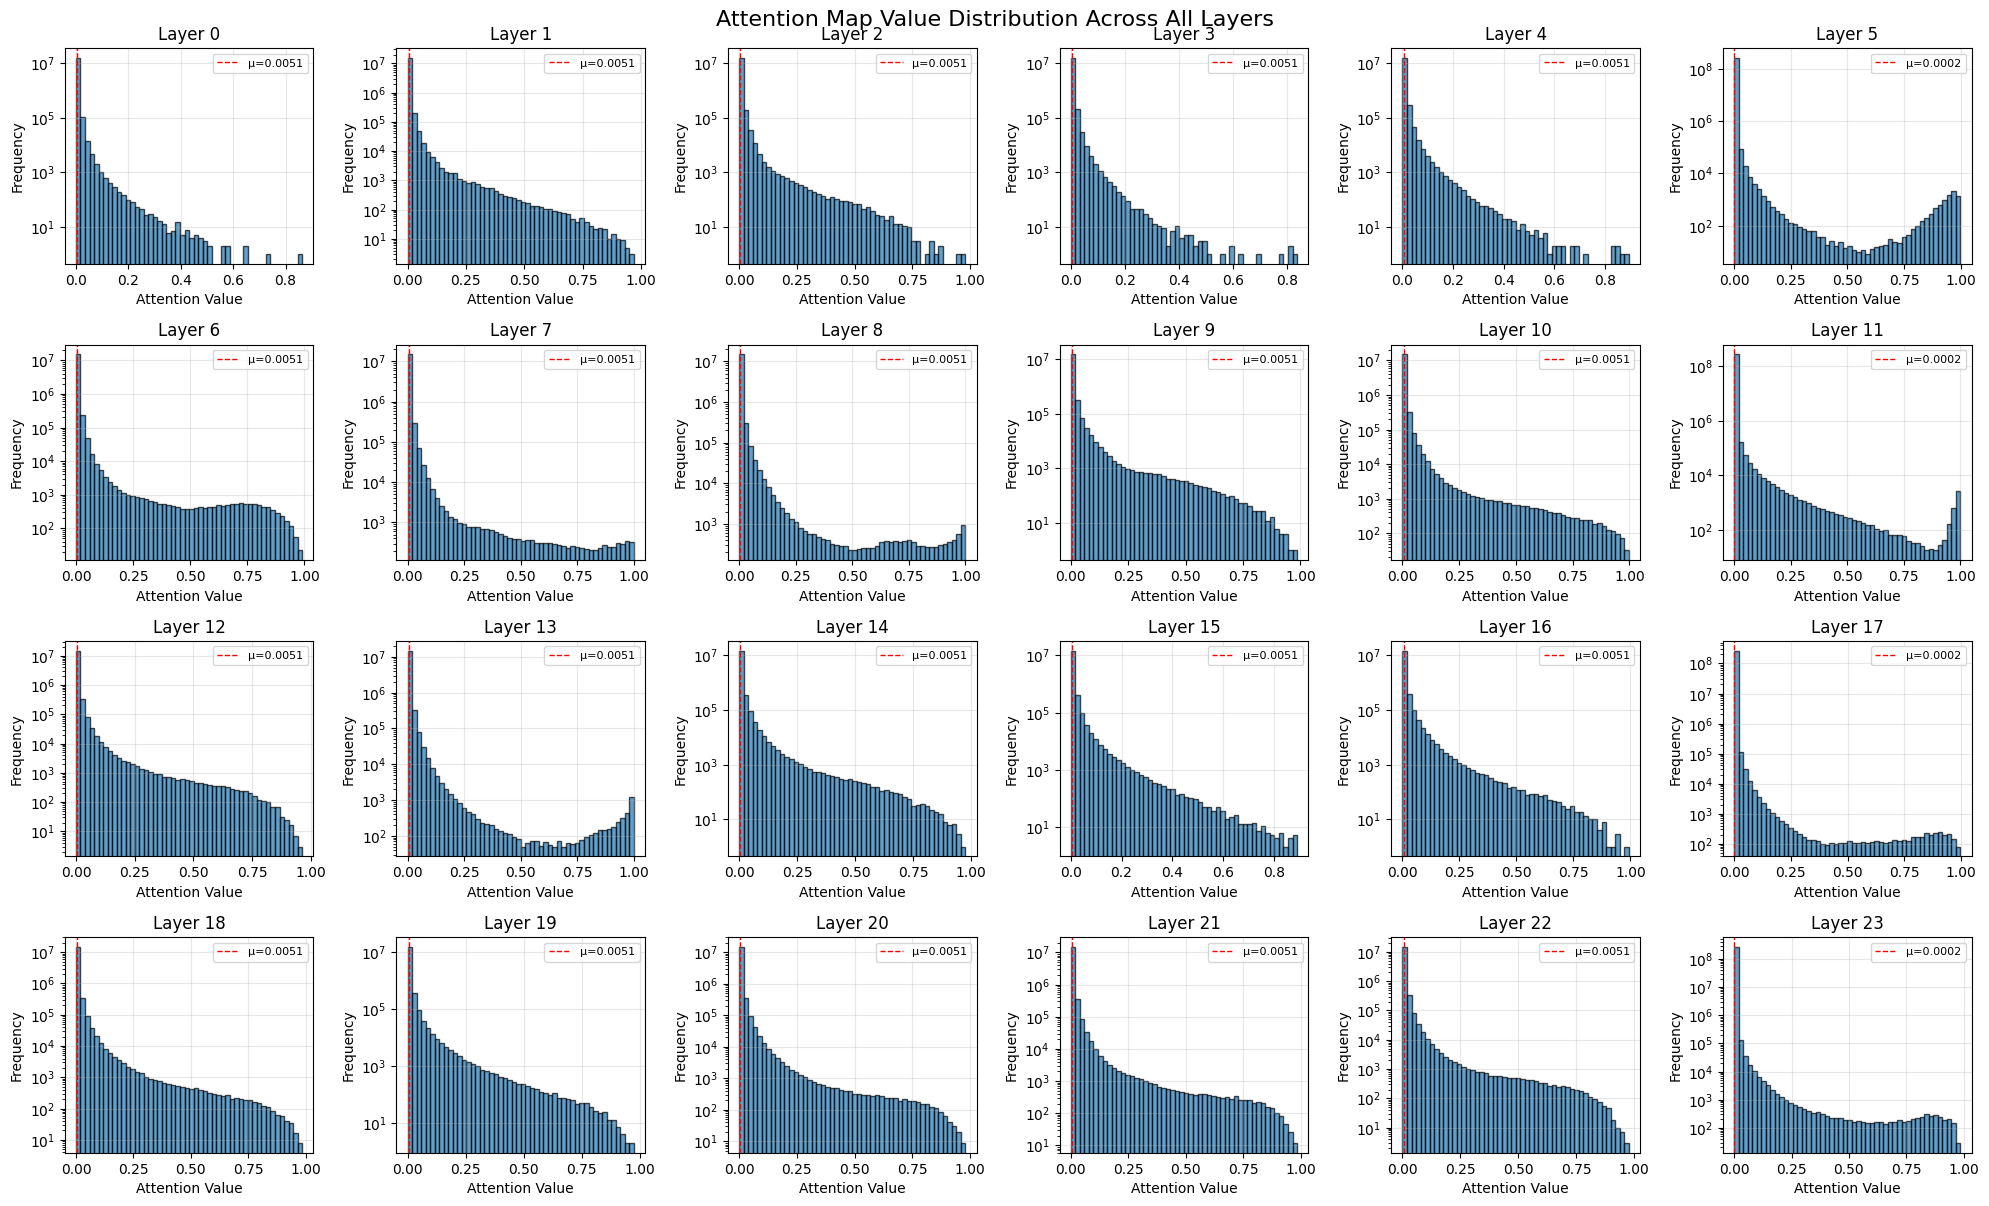

: 

In [ ]:
# Plot distribution of attention map values across different layers
import numpy as np

fig, axes = plt.subplots(4, 6, figsize=(20, 12))
axes = axes.flatten()

for layer_idx in range(24):
    attn = get_attention_map_hat(layer_idx)
    attn_flat = attn.flatten()
    
    axes[layer_idx].hist(attn_flat, bins=50, alpha=0.7, edgecolor='black',  log=True)
    axes[layer_idx].set_title(f'Layer {layer_idx}')
    axes[layer_idx].set_xlabel('Attention Value')
    axes[layer_idx].set_ylabel('Frequency')
    axes[layer_idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(attn_flat)
    std_val = np.std(attn_flat)
    axes[layer_idx].axvline(mean_val, color='r', linestyle='--', linewidth=1, label=f'μ={mean_val:.4f}')
    axes[layer_idx].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Attention Map Value Distribution Across All Layers', y=1.001, fontsize=16)
plt.show()